In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import gc, random
from pathlib import Path

import cv2
import torch
import numpy as np
from torchvision.transforms import v2

import umap

from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import trustworthiness
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Import your modules
from src.dino import ConvNeXtV2
from src.utils import show_images, load_backbone, run_inference

WEIGHTS_DIR = Path("../weights/")
EPOCH_COUNT = len(list(WEIGHTS_DIR.iterdir())) - 2

DEVICE = torch.device("cuda")  # ConvNeXtV2 doesn't support CPU

SEED = 42
DATASET_PATH = Path("../data/labelled/SASSED/tiles/")
DATA_EXT = '.png'
DATA_FILES = sorted([im.stem for im in DATASET_PATH.glob(f"*{DATA_EXT}")])
N = len(DATA_FILES)


/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:243: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Pl

In [3]:
def get_outputs(model: ConvNeXtV2):
    patches = [
        cv2.imread(str(DATASET_PATH / f"{DATA_FILES[i]}{DATA_EXT}"), cv2.IMREAD_GRAYSCALE)
        for i in range(N)
    ]

    embeds, stages = [], []
    for p in patches:
        cls, flat_patches, outputs = run_inference(model, torch.from_numpy(p[np.newaxis, :, :]))

        embeds.append(cls)
        stages.append(outputs)

    return patches, np.array(embeds), stages


def get_visualizations(processed):
    visuals = []
    for i in range(5):
        batch = np.vstack([p[i].reshape(-1, p[i].shape[-1]) for p in processed])
        batch = (batch - np.mean(batch, axis=0)) / np.std(batch, axis=0)  # Normalize each dimension

        pca = PCA(n_components=3, whiten=True)
        pca.fit(batch)

        visuals.append([])
        for j in range(len(processed)):
            features = processed[j][i]

            patch_dim = features.shape[0]

            # Transform ALL features of this image to pixel space
            pca_patch = features.reshape(-1, features.shape[-1])
            pca_patch = pca.transform(pca_patch)  # (H*W, 3)
            pca_patch = pca_patch.reshape(patch_dim, patch_dim, 3)

            # Sigmoid & Scaling for more vibrant colors
            pca_patch = 1.0 / (1.0 + np.exp(-2 * pca_patch))
            pca_patch = (255 * pca_patch).astype(np.uint8)

            visuals[-1].append(pca_patch)

    return visuals


def two_nn(X: np.ndarray) -> float:
    '''
    Estimates intrinsic dimension using the Two-NN algorithm (Facco et al., 2017).

    Measures the true manifold dimension where your data lives, regardless of the ambient embedding dimension C.
    If the intrinsic dimension is low (e.g., << C), the data lies on low-dimensional manifolds where linear
    probes often perform very well.
    '''
    nbrs = NearestNeighbors(n_neighbors=3, algorithm="auto").fit(X)
    distances, _ = nbrs.kneighbors(X)

    # r1: dist to 1st nearest neighbor, r2: dist to 2nd nearest neighbor
    r1, r2 = distances[:, 1], distances[:, 2]

    # Filter identical points to avoid division by zero
    valid = (r1 > 0) & (r2 > r1)
    mu = r2[valid] / r1[valid]

    # Empirical CDF
    N = len(mu)
    mu_sorted = np.sort(mu)
    F = np.arange(1, N) / N

    # Slope of -ln(1 - F(mu)) vs ln(mu) through origin gives intrinsic dimension
    x_val = np.log(mu_sorted[:-1])
    y_val = -np.log(1 - F)

    # Fit line through origin via least squares
    dim = np.sum(x_val * y_val) / np.sum(x_val**2)
    return dim


def compute_hdbscan(X, n_dims: int = 16):
    '''
    Noise Fraction:
        < 20:
            Embeddings have dense local neighborhoods.
        > 60:
            Embeddings are too diffuse, uniform, or dimensional collapse has inflated neighbor distances.
    Mean Cluster Membership Probability:
        Values close to 1.0 mean samples sit deep inside stable, well-separated density basins rather than ambiguous cluster boundaries.
    '''
    X_norm = normalize(X, norm='l2', axis=1)  # (N, 768)

    # Use UMAP to reduce the dimensionality to increase density for HDBSCAN
    # https://arxiv.org/abs/1802.03426
    reducer = umap.UMAP(n_neighbors=10, n_components=n_dims, random_state=SEED)
    X_umap = reducer.fit_transform(X_norm)

    # [1] Campello, R. J., Moulavi, D., & Sander, J. Density-based clustering based on hierarchical density estimates.
    clusterer = HDBSCAN(
        min_cluster_size=30,
        min_samples=5,
        cluster_selection_method='eom',
        n_jobs=-1,
        copy=True
    )

    labels = clusterer.fit_predict(X_umap)
    probabilities = clusterer.probabilities_  # Membership strength [0.0, 1.0]

    # Analyze output metrics
    mask = labels != -1
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    sil_score = silhouette_score(X_umap[mask], labels[mask], random_state=SEED) if num_clusters > 1 and np.sum(mask) > num_clusters else -1.0
    noise_ratio = np.mean(~mask)
    avg_confidence = np.mean(probabilities[labels != -1]) if num_clusters > 0 else 0.0

    return labels, probabilities, num_clusters, sil_score, noise_ratio, avg_confidence


def compute_kmeans(X: np.array, n_clusters: int = 16):
    '''
    The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean
    nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is (b - a) / max(a, b).
    It essentially measures whether data points form dense, isolated, spherical balls in Euclidean space or not.

    Trustworthiness (Venna & Kaski) measures whether points that are neighbors in the original space
    remain neighbors after a projection or embedding transformation, penalizing "false positive" neighbors.
    '''

    X_norm = normalize(X, norm='l2', axis=1)  # (N, 768)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=SEED,
        n_init='auto'
    )

    cluster_labels = kmeans.fit_predict(X_norm)  # (N, )
    centroids = normalize(kmeans.cluster_centers_, norm='l2', axis=1)  # (n_clusters, 768)

    # Reference: https://www.sciencedirect.com/science/article/pii/0377042787901257
    sil_score = silhouette_score(
        X_norm,
        cluster_labels,
        metric='euclidean',
        random_state=SEED
    )

    # Laurens van der Maaten. Learning a Parametric Embedding by Preserving Local Structure. Proceedings of the Twelfth International Conference on Artificial Intelligence and Statistics, PMLR 5:384-391, 2009.
    pca = PCA(n_components=n_clusters, random_state=SEED)
    X_pca = pca.fit_transform(X_norm)
    trust_score = trustworthiness(X_norm, X_pca, n_neighbors=10)

    return centroids, X_norm, sil_score, trust_score


def evaluate(patches, embeds, n_clusters: int = 32):
    two_nn_score = two_nn(embeds)
    labels, probabilities, num_clusters, hdb_sil_score, noise_ratio, avg_confidence = compute_hdbscan(
        embeds,
        n_dims=round(two_nn_score + 3)  # Two NN provides a floor for dimension reduction. Add 3 extra dims for some flexibility.
    )
    centroids, norm_embeds, sil_score, trust_score = compute_kmeans(embeds, n_clusters=n_clusters)

    # --- Formatted Summary Printout ---
    print(f"\n{'='*45}")
    print(f" Evaluation Summary")
    print(f"{'='*45}")
    print(f" + Manifold Geometry:")
    print(f"   - Intrinsic Dimension (Two-NN) : {two_nn_score:.2f}")
    print(f"   - Neighborhood Trust (PCA-32)  : {trust_score:.4f}")
    
    print(f"\n + K-Means (k={n_clusters}):")
    print(f"   - Silhouette Score             : {sil_score:.4f}")

    print(f"\n + HDBSCAN (Density Discovery):")
    print(f"   - Discovered Clusters          : {num_clusters}")
    print(f"   - Silhouette (non-noise)       : {hdb_sil_score:.4f}")
    print(f"   - Noise Ratio                  : {noise_ratio * 100:.1f}%")
    print(f"   - Mean Cluster Confidence      : {avg_confidence:.3f}")
    print(f"{'='*45}\n")

    return labels, probabilities, patches, norm_embeds, centroids


In [4]:
# Compute stats and do a sweep to determine optimal number of clusters

model = load_backbone(WEIGHTS_DIR / "checkpoint_latest.pth")
patches, embeds, stages = get_outputs(model)

two_nn_score = two_nn(embeds)
labels, probabilities, num_clusters, sil_score, noise_ratio, avg_confidence = compute_hdbscan(embeds, n_dims=round(two_nn_score + 3))

# --- Global Diagnostics ---
print(f"\n{'='*48}")
print(" Embedding Diagnostics & K-Means Sweep")
print(f"{'='*48}")
print(f" + Intrinsic Dimension (Two-NN) : {two_nn_score:.2f}")
print(f" + HDBSCAN Clusters Found       : {num_clusters}")
print(f"   - Noise Ratio                : {noise_ratio * 100:.1f}%")
print(f"   - Mean Confidence            : {avg_confidence:.3f}")
print(f"   - Filtered Silhouette        : {sil_score:.4f}")

# --- K-Means Sweep Table ---
print(f"\n{'-'*48}")
print(f" {'k':>4} | {'Silhouette':>12} | {'Trustworthiness':>16}")
print(f"{'-'*48}")

for n_cluster in range(4, 65, 4):
    centroids, X_norm, sil_score, trust_score = compute_kmeans(embeds, n_clusters=n_cluster)
    print(f" {n_cluster:>4} | {sil_score:>12.4f} | {trust_score:>16.4f}")

print(f"{'='*48}\n")

/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



 Embedding Diagnostics & K-Means Sweep
 + Intrinsic Dimension (Two-NN) : 4.09
 + HDBSCAN Clusters Found       : 2
   - Noise Ratio                : 0.0%
   - Mean Confidence            : 0.994
   - Filtered Silhouette        : 0.5826

------------------------------------------------
    k |   Silhouette |  Trustworthiness
------------------------------------------------
    4 |       0.2801 |           0.9864
    8 |       0.2223 |           0.9973
   12 |       0.1962 |           0.9992
   16 |       0.1898 |           0.9996
   20 |       0.1825 |           0.9997
   24 |       0.1876 |           0.9998
   28 |       0.1955 |           0.9999
   32 |       0.2050 |           0.9999
   36 |       0.1964 |           0.9999
   40 |       0.1950 |           0.9999
   44 |       0.1870 |           0.9999
   48 |       0.1872 |           0.9999
   52 |       0.1871 |           1.0000
   56 |       0.1838 |           1.0000
   60 |       0.1848 |           1.0000
   64 |       0.1798 |    

In [5]:
# Compute stats on DINO
labels, probabilities, patches, norm_embeds, centroids = evaluate(patches, embeds, n_clusters=4)

/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



 Evaluation Summary
 + Manifold Geometry:
   - Intrinsic Dimension (Two-NN) : 4.09
   - Neighborhood Trust (PCA-32)  : 0.9864

 + K-Means (k=4):
   - Silhouette Score             : 0.2801

 + HDBSCAN (Density Discovery):
   - Discovered Clusters          : 2
   - Silhouette (non-noise)       : 0.5826
   - Noise Ratio                  : 0.0%
   - Mean Cluster Confidence      : 0.994



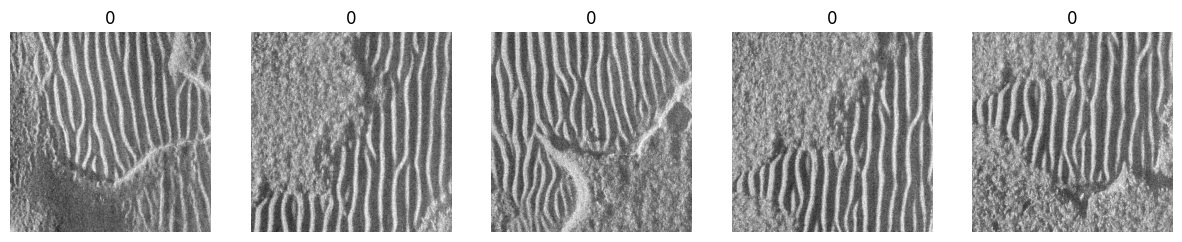

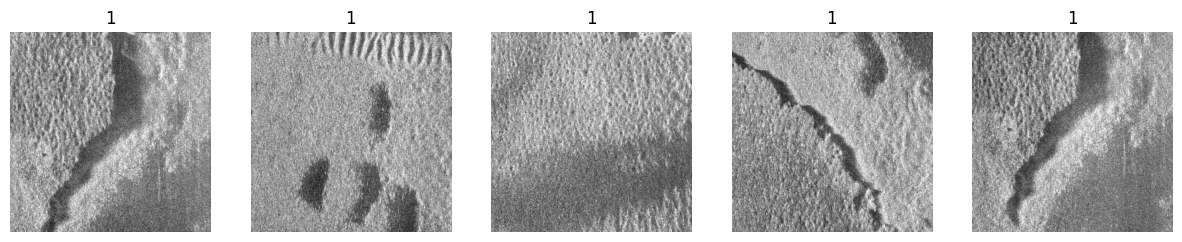

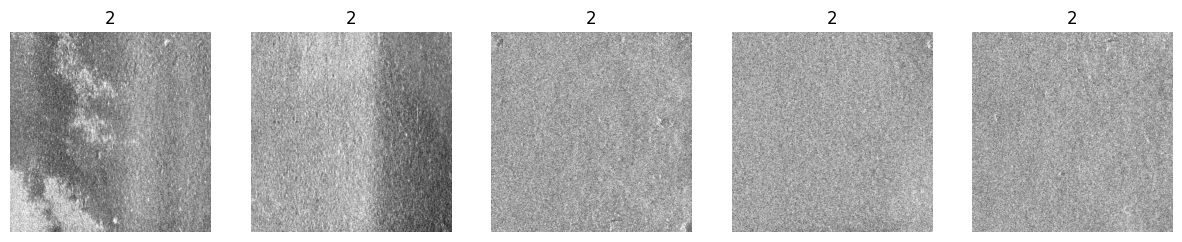

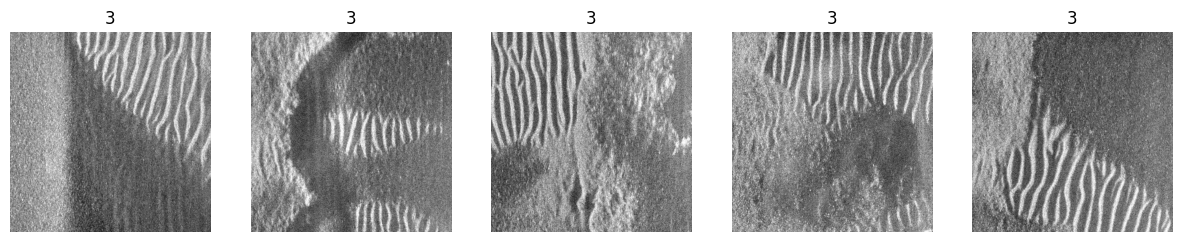

In [6]:
# Visualize 5 top matches of each K-Means cluster
for i in range(centroids.shape[0]):
    centroid = centroids[i]

    indices = np.argsort(norm_embeds @ centroid)
    show_images([(patches[j], str(i)) for j in indices[-5:]])

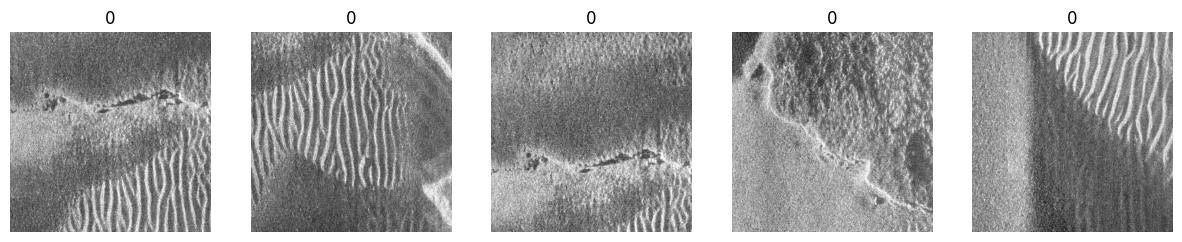

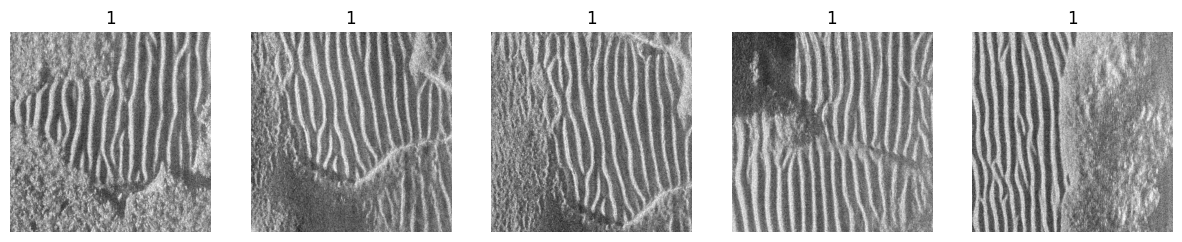

In [7]:
# Visualize 5 top matches of each HDBSCAN cluster
unique_labels = np.sort(np.unique(labels[labels != -1]))
for label in unique_labels:
    mask = labels == label

    probs = np.zeros_like(probabilities)
    probs[mask] = probabilities[mask]

    indices = np.argsort(probs)
    show_images([(patches[j], str(label)) for j in indices[-5:]])

In [8]:
visuals = get_visualizations(stages)

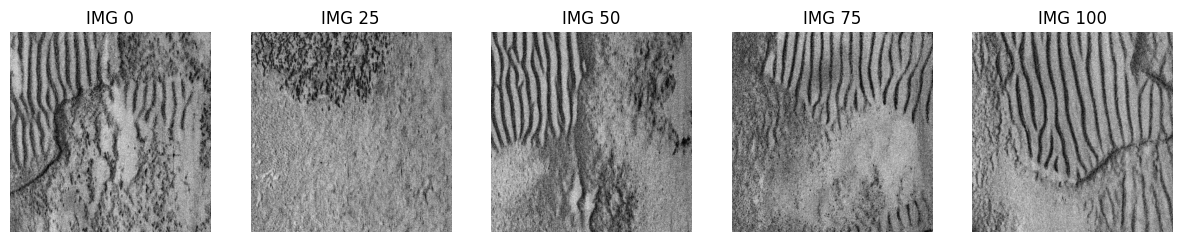

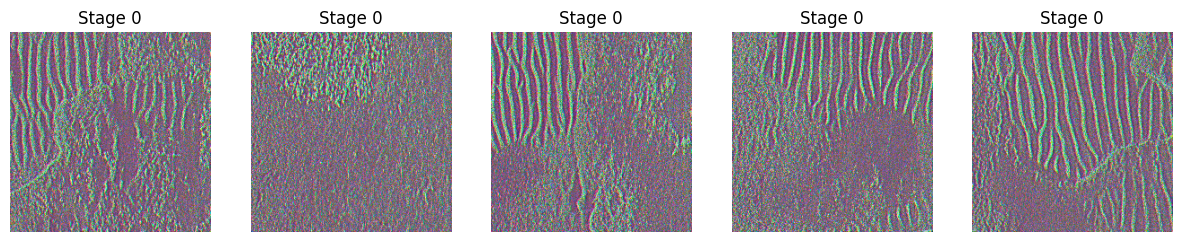

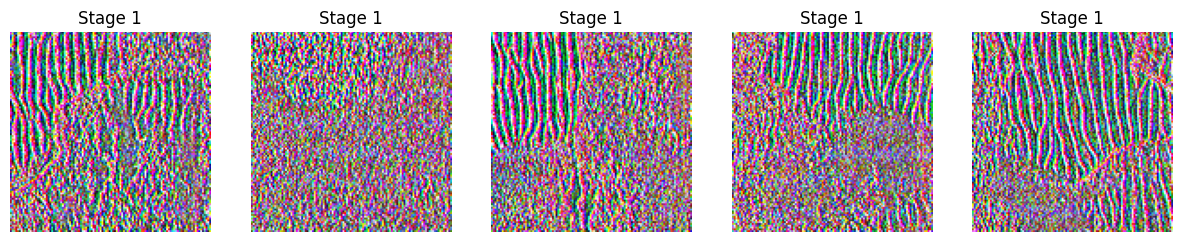

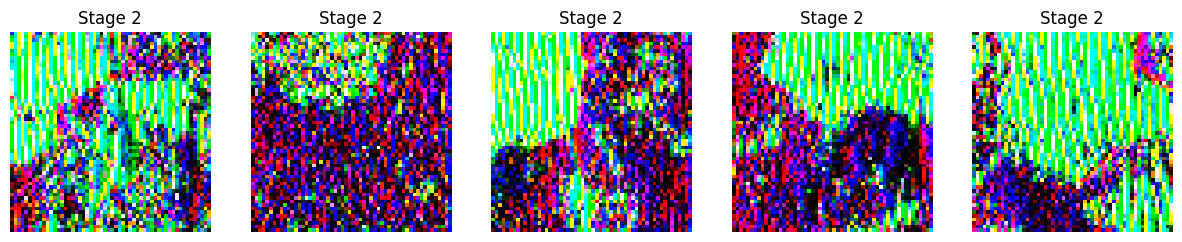

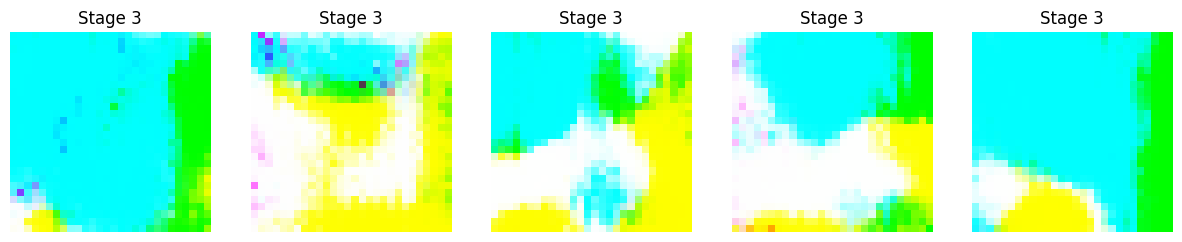

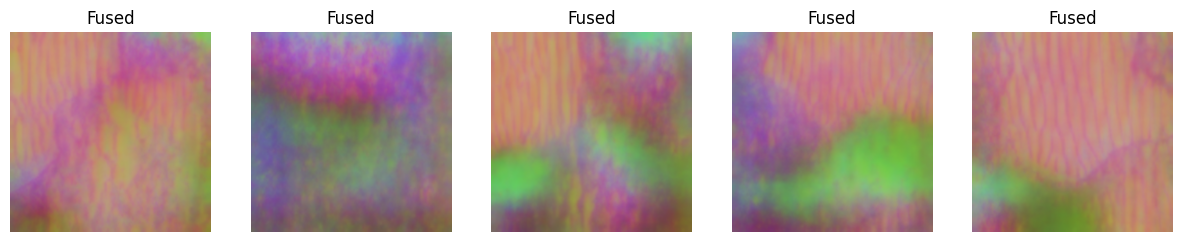

In [9]:
indices = [i for i in range(0, N, N // 5)][:5]
show_images([(
    cv2.cvtColor((255 * patches[i]).astype(np.uint8), cv2.COLOR_GRAY2RGB), f"IMG {i}")
    for i in indices
])

for stage in range(len(visuals) - 1):
    show_images([
        (visuals[stage][i], f"Stage {stage}")
        for i in indices
    ], normalize=False, cmap=None)

show_images([
    (visuals[-1][i], f"Fused")
    for i in indices
], normalize=False, cmap=None)